In [1]:
"""
energy_profit_plots.ipynb

Combines:
- A demo / warm-up of the per-call GPU energy measurement (loads a small
  model, generates a short story, measures generation and scoring energy).
- Loading of pre-computed per-prompt energy results from
  ``outputs/energy_outputs/`` for five models, summary statistics,
  scatter plots of (out_length, energy).
- Loading of heuristic-misreporting "plausibility" pickles from
  ``outputs/heuristic_new/<short>/`` and computing the provider's
  "increase in utility / profit" as a function of margin rho.

All paths are resolved relative to ``WORK_DIR``.
"""

%matplotlib inline

import os
import sys
import pickle
import time
import threading

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pynvml
import torch
from matplotlib.patches import Patch
from transformers import AutoTokenizer, AutoModelForCausalLM

# Resolve project paths from the notebook's location: <work>/notebooks/...
WORK_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))
ENERGY_DIR = os.path.join(WORK_DIR, "outputs", "energy_outputs")
HEUR_DIR = os.path.join(WORK_DIR, "outputs", "heuristic_new")
MODEL_CACHE = os.path.join(WORK_DIR, "models")
FIGURES_DIR = os.path.join(WORK_DIR, "figures")

sys.path.insert(0, os.path.join(WORK_DIR, "src"))
import utils  # noqa: E402

# Short name -> (filename stem used in outputs/, HuggingFace model id).
MODEL_INFO = {
    "L1B": ("Llama-3.2-1B-Instruct",        "meta-llama/Llama-3.2-1B-Instruct"),
    "L3B": ("Llama-3.2-3B-Instruct",        "meta-llama/Llama-3.2-3B-Instruct"),
    "G1B": ("Gemma-3-1b-it",                "google/gemma-3-1b-it"),
    "G4B": ("Gemma-3-4b-it",                "google/gemma-3-4b-it"),
    "M8B": ("Ministral-8B-Instruct-2410",   "mistralai/Ministral-8B-Instruct-2410"),
}

# Half-width multiplier for the standard-deviation bands drawn around the mean.
t_val = 2.3


In [2]:
# Demo / warm-up: load gemma-3-1b-it once for use by the two cells
# below (single-prompt generation + per-call energy measurement). Not
# used by the analysis / plotting cells that follow.

model = AutoModelForCausalLM.from_pretrained(
    "google/gemma-3-1b-it",
    cache_dir=MODEL_CACHE,
    torch_dtype="auto",
    device_map="auto",
)
tokenizer = AutoTokenizer.from_pretrained(
    "google/gemma-3-1b-it",
    cache_dir=MODEL_CACHE,
)


Loading weights: 100%|██████████| 340/340 [00:29<00:00, 11.70it/s]


In [ ]:
# Demo: single-prompt generation with the warm-up model loaded above.
messages = [
    {"role": "system", "content": "You are a helpful assistant. "},
    {"role": "user", "content": "Tell me a story"},
]

prompt = tokenizer.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=True,
)

inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

outputs = model.generate(**inputs, max_new_tokens=400, temperature=1.0)

input_length = inputs["input_ids"].shape[1]
generated_tokens = outputs[0][input_length:]
print("Number of generated tokens:", len(generated_tokens))
generated_text = tokenizer.decode(generated_tokens, skip_special_tokens=True)
print(generated_text)


In [ ]:
# Demo: measure GPU energy during one generate() and one scoring forward
# pass. Mirrors the logic of ``src/energy.py`` so it can be inspected
# interactively without launching a SLURM job.

# Initialize NVML and get GPU handle.
pynvml.nvmlInit()
handle = pynvml.nvmlDeviceGetHandleByIndex(0)


def get_power_usage():
    """Current GPU power draw in watts."""
    return pynvml.nvmlDeviceGetPowerUsage(handle) / 1000


def measure_energy_during(func, *args, **kwargs):
    """Run ``func`` while sampling GPU power, and return its result plus
    elapsed wall time (s), average power (W), and integrated energy (J)."""
    power_samples = []
    start_time = time.time()

    def sample_power():
        while not stop_sampling.is_set():
            power_samples.append(get_power_usage())
            time.sleep(0.1)

    stop_sampling = threading.Event()
    sampler_thread = threading.Thread(target=sample_power)
    sampler_thread.start()

    result = func(*args, **kwargs)

    stop_sampling.set()
    sampler_thread.join()

    duration = time.time() - start_time
    avg_power = sum(power_samples) / len(power_samples) if power_samples else 0
    energy_joules = avg_power * duration
    return result, duration, avg_power, energy_joules


def generate_text(model, tokenizer, inputs, **gen_kwargs):
    return model.generate(**inputs, **gen_kwargs)


def score_sequence(model, input_ids, attention_mask=None):
    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        return outputs.logits


messages = [
    {"role": "system", "content": "You are a helpful assistant."},
    {"role": "user", "content": "Tell me a story about"},
]
prompt = tokenizer.apply_chat_template(
    messages, tokenize=False, add_generation_prompt=True,
)
inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

# 1) Measure energy during generation.
generated_outputs, gen_time, gen_power, gen_energy = measure_energy_during(
    generate_text,
    model,
    tokenizer,
    inputs,
    max_new_tokens=300,
    temperature=1.0,
    repetition_penalty=1.2,
    eos_token_id=tokenizer.eos_token_id,
)

input_len = inputs["input_ids"].shape[1]
generated_tokens = generated_outputs[0][input_len:].unsqueeze(0).to(model.device)

print(f"Generation time: {gen_time:.2f} s, avg power: {gen_power:.2f} W, energy: {gen_energy:.2f} J")
print(f"Number of generated tokens: {generated_tokens.shape[1]}")
generated_text = tokenizer.decode(generated_tokens[0], skip_special_tokens=True)
print("Generated text:\n", generated_text)

# 2) Prepare full sequence for scoring.
full_sequence = torch.cat([inputs["input_ids"], generated_tokens], dim=1).to(model.device)
attention_mask = None
if "attention_mask" in inputs:
    attn_mask = inputs["attention_mask"]
    gen_mask = torch.ones((1, generated_tokens.shape[1]), dtype=attn_mask.dtype).to(model.device)
    attention_mask = torch.cat([attn_mask, gen_mask], dim=1)

# 3) Measure energy during scoring (forward pass).
logits, score_time, score_power, score_energy = measure_energy_during(
    score_sequence,
    model,
    full_sequence,
    attention_mask=attention_mask,
)
print(f"Scoring time: {score_time:.2f} s, avg power: {score_power:.2f} W, energy: {score_energy:.2f} J")

pynvml.nvmlShutdown()


# Plots


In [3]:
# Load pre-computed per-prompt energy results for the five models from
# ENERGY_DIR. Each pickle is a list of dicts with keys
# {out_length, gen_energy, score_energy, decoded_text}.

ENERGY_DATA = {}
for short, (model_str, _) in MODEL_INFO.items():
    with open(os.path.join(ENERGY_DIR, f"energy_results_{model_str}.pkl"), "rb") as f:
        ENERGY_DATA[short] = pickle.load(f)

# Backwards-compatible aliases used by the cells below.
data_L1 = ENERGY_DATA["L1B"]
data_L3 = ENERGY_DATA["L3B"]
data_G1 = ENERGY_DATA["G1B"]
data_G4 = ENERGY_DATA["G4B"]
data_M8 = ENERGY_DATA["M8B"]


<Figure size 640x480 with 0 Axes>

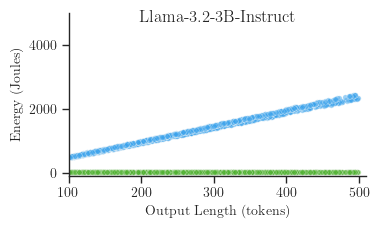

In [4]:
# Scatter plot: per-prompt scoring energy and generation energy versus
# output length, for Llama-3.2-3B-Instruct.

plt.clf()
sns.set_theme(context="paper", style="ticks", font_scale=1)
palette = sns.color_palette("husl", 3)
utils.latexify()  # Computer Modern, with TeX

fig_width, fig_height = utils.get_fig_dim(469, fraction=0.6)
fig, ax = plt.subplots(figsize=(fig_width, fig_height))

data_frame = pd.DataFrame(data_L3)
sns.scatterplot(data=data_frame, x="out_length", y="gen_energy",
                label="Generation Energy", color=palette[2], s=15, alpha=0.5, legend=False)
sns.scatterplot(data=data_frame, x="out_length", y="score_energy",
                label="Scoring Energy", color=palette[1], s=15, alpha=0.5, legend=False)

ax.set_xlabel("Output Length (tokens)")
ax.set_ylabel("Energy (Joules)")
sns.despine(ax=ax)
ax.set_xlim(100, 510)
ax.set_ylim(-100, 5000)
ax.text(0.5, 0.95, "Llama-3.2-3B-Instruct", transform=ax.transAxes,
        ha="center", fontsize=12)

fig.tight_layout()
# fig.savefig(os.path.join(FIGURES_DIR, "energy", "energy_L3.pdf"), dpi=300)


In [5]:
# Per-model average scoring cost and per-token generation cost, with
# their standard deviations. Also computes the (gen/tok) / score ratio
# used downstream as ``c0 / c_v`` in the profit formulas.

gen_to_score_ratios = {}
for short, d in ENERGY_DATA.items():
    score_costs = [r["score_energy"] for r in d]
    gen_per_tok = [r["gen_energy"] / r["out_length"] for r in d]
    score_mean, score_std = np.mean(score_costs), np.std(score_costs)
    gen_mean, gen_std = np.mean(gen_per_tok), np.std(gen_per_tok)
    print(f"Average scoring cost for {short}: {score_mean}")
    print(f"Standard deviation: {score_std}")
    print(f"Average generation cost per token for {short}: {gen_mean}")
    print(f"Standard deviation: {gen_std}")
    print("----------------------------------------")
    gen_to_score_ratios[short] = gen_mean / score_mean

# Backwards-compatible aliases (used by cell 13 below).
gen_to_score_ratio_L1 = gen_to_score_ratios["L1B"]
gen_to_score_ratio_L3 = gen_to_score_ratios["L3B"]
gen_to_score_ratio_G1 = gen_to_score_ratios["G1B"]
gen_to_score_ratio_G4 = gen_to_score_ratios["G4B"]
gen_to_score_ratio_M8 = gen_to_score_ratios["M8B"]


Average scoring cost for L1:  15.188899605847121
Standard deviation:  0.17998998395693833
Average generation cost per token for L1:  2.642089241176297
Standard deviation:  0.13943733022530838
----------------------------------------
Average scoring cost  for L3:  15.903015182751416
Standard deviation:  0.2251979090361956
Average generation cost per token for L3:  4.805773798810014
Standard deviation:  0.151391018785545
----------------------------------------
Average scoring cost for G1:  12.737264256523133
Standard deviation:  0.08006648731049276
Average generation cost per token for G1:  6.482024071432994
Standard deviation:  0.20635111273991025
----------------------------------------
Average scoring cost for G4:  33.51756702235285
Standard deviation:  4.285303360603443
Average generation cost per token for G4:  9.992732220092629
Standard deviation:  0.1786623631454739
----------------------------------------
Average scoring cost  for M8:  17.740518088517906
Standard deviation:  0.2

In [6]:
# Per-model standard error on the per-token generation cost and on the
# scoring cost (sigma / sqrt(N)).

cost_errors = {}
for short, d in ENERGY_DATA.items():
    n = len(d)
    gen_per_tok = [r["gen_energy"] / r["out_length"] for r in d]
    score_costs = [r["score_energy"] for r in d]
    cost_errors[short] = {
        "gen_cost_error": np.std(gen_per_tok) / np.sqrt(n),
        "score_cost_error": np.std(score_costs) / np.sqrt(n),
    }
    print(f"Generation cost error for {short}: {cost_errors[short]['gen_cost_error']}")
    print(f"Scoring cost error for {short}: {cost_errors[short]['score_cost_error']}")
    print("----------------------------------------")

# Backwards-compatible aliases.
gen_cost_error_L1   = cost_errors["L1B"]["gen_cost_error"]
score_cost_error_L1 = cost_errors["L1B"]["score_cost_error"]
gen_cost_error_L3   = cost_errors["L3B"]["gen_cost_error"]
score_cost_error_L3 = cost_errors["L3B"]["score_cost_error"]
gen_cost_error_G1   = cost_errors["G1B"]["gen_cost_error"]
score_cost_error_G1 = cost_errors["G1B"]["score_cost_error"]
gen_cost_error_G4   = cost_errors["G4B"]["gen_cost_error"]
score_cost_error_G4 = cost_errors["G4B"]["score_cost_error"]
gen_cost_error_M8   = cost_errors["M8B"]["gen_cost_error"]
score_cost_error_M8 = cost_errors["M8B"]["score_cost_error"]


Generation cost error for L1:  0.004409395543650139
Scoring cost error for L1:  0.005691783053210911
----------------------------------------
Generation cost error for L3:  0.004787404366556604
Scoring cost error for L3:  0.007121383168617922
----------------------------------------
Generation cost error for G1:  0.006525395139683049
Scoring cost error for G1:  0.0025319246415012628
----------------------------------------
Generation cost error for G4:  0.005649799996878225
Scoring cost error for G4:  0.1355131908428075
----------------------------------------
Generation cost error for M8:  0.009214540908840036
Scoring cost error for M8:  0.008255686689438334


In [7]:
# Per-model standard error on the (gen/tok) / score ratio.

ratio_errors = {}
for short, d in ENERGY_DATA.items():
    gen_per_tok = [r["gen_energy"] / r["out_length"] for r in d]
    score_costs = [r["score_energy"] for r in d]
    ratio_errors[short] = np.std(gen_per_tok) / np.mean(score_costs)

for short in ENERGY_DATA:
    print(f"Generation to scoring ratio for {short}: "
          f"{gen_to_score_ratios[short]} +/- {ratio_errors[short]}")

# Backwards-compatible aliases.
gen_to_score_ratio_L1_error = ratio_errors["L1B"]
gen_to_score_ratio_L3_error = ratio_errors["L3B"]
gen_to_score_ratio_G1_error = ratio_errors["G1B"]
gen_to_score_ratio_G4_error = ratio_errors["G4B"]
gen_to_score_ratio_M8_error = ratio_errors["M8B"]


Generation to scoring ratio for L1:  0.1739486934365672  +/-  0.009180212776680054
Generation to scoring ratio for L3:  0.30219261841756956  +/-  0.009519642473192464
Generation to scoring ratio for G1:  0.5089023781628269  +/-  0.01620058346785352
Generation to scoring ratio for G4:  0.2981341758316909  +/-  0.005330409663276694
Generation to scoring ratio for M8:  0.4138803339935397  +/-  0.016425076606749103


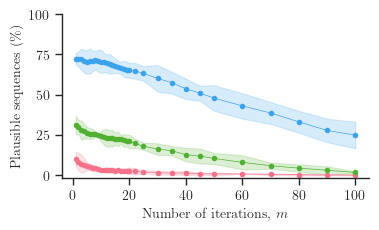

[10.16666667  8.33333333  7.16666667  6.25        5.41666667  5.25
  4.33333333  4.16666667  3.66666667  3.33333333  3.33333333  3.16666667
  2.91666667  3.16666667  2.75        2.91666667  2.83333333  2.83333333
  2.66666667  2.83333333  2.25        1.91666667  1.5         1.25
  1.33333333  0.83333333  0.75        0.75        0.5         0.25
  0.08333333  0.08333333]
[31.08333333 29.75       27.91666667 27.25       26.41666667 25.66666667
 25.83333333 25.58333333 24.66666667 24.         23.75       23.08333333
 22.83333333 22.83333333 22.58333333 22.58333333 22.16666667 21.58333333
 21.33333333 20.91666667 19.66666667 17.91666667 16.16666667 15.16666667
 12.66666667 11.83333333 10.33333333  7.91666667  5.83333333  4.33333333
  3.          1.66666667]
[72.33333333 72.08333333 72.         70.75       70.41666667 70.83333333
 70.91666667 71.33333333 71.08333333 70.58333333 70.         69.41666667
 69.08333333 68.58333333 68.         67.33333333 66.5        66.08333333
 65.58333333 65.0

In [8]:
# Load the Ministral-8B heuristic-misreporting pickles for T=1.3 at three
# top-p values and plot the percentage of plausible sequences vs the
# number of split iterations.

SPLITS_T13 = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19,
              20, 22, 25, 30, 35, 40, 45, 50, 60, 70, 80, 90, 100]


def load_heur(short_name, T, top_p, splits=None):
    """Load a heuristic_misreporting pickle from
    ``HEUR_DIR/<short_name>/heuristic_model_<MS>_T_<T>_splits_<splits>_numseq_3_p_<P>_k_None_prompt_idare you .pkl``.

    When ``splits`` is ``None`` (the T=1.45 file convention), the splits
    list is omitted from the filename and the ``_k_None_prompt_id...``
    suffix is dropped for M8B and L1B.
    """
    model_str = MODEL_INFO[short_name][0]
    if splits is None:
        # T=1.45 convention; two sub-flavors depending on the model.
        if short_name in ("M8B", "L1B"):
            fname = f"heuristic_model_{model_str}_T_{T}_splits_numseq_3_p_{top_p}.pkl"
        else:
            fname = (f"heuristic_model_{model_str}_T_{T}_splits_"
                     f"numseq_3_p_{top_p}_k_None_prompt_idare you .pkl")
    else:
        fname = (f"heuristic_model_{model_str}_T_{T}_splits_{splits}_"
                 f"numseq_3_p_{top_p}_k_None_prompt_idare you .pkl")
    with open(os.path.join(HEUR_DIR, short_name, fname), "rb") as f:
        return pickle.load(f)


data_09  = load_heur("M8B", 1.3, 0.9,  splits=SPLITS_T13)
data_095 = load_heur("M8B", 1.3, 0.95, splits=SPLITS_T13)
data_099 = load_heur("M8B", 1.3, 0.99, splits=SPLITS_T13)

num_prompts = len(data_09["generated_outputs"][0])
splits = SPLITS_T13
indices = list(range(len(splits)))


def stack_percentages(data):
    """Convert ``data["top_p_count"]`` (one row per replicate) into a
    list of np arrays with values as percentages of ``num_prompts``."""
    return [np.array([d / num_prompts * 100 for d in row])
            for row in data["top_p_count"]]


percentage_09  = stack_percentages(data_09)
percentage_095 = stack_percentages(data_095)
percentage_099 = stack_percentages(data_099)

mean_09  = np.mean(np.stack(percentage_09[:3],  axis=0), axis=0)
std_09   = np.std(np.stack(percentage_09[:3],  axis=0), axis=0)
mean_095 = np.mean(np.stack(percentage_095[:3], axis=0), axis=0)
std_095  = np.std(np.stack(percentage_095[:3], axis=0), axis=0)
mean_099 = np.mean(np.stack(percentage_099[:3], axis=0), axis=0)
std_099  = np.std(np.stack(percentage_099[:3], axis=0), axis=0)

splits_new = np.array(splits)[indices]
mean_09_new  = mean_09[indices]
mean_095_new = mean_095[indices]
mean_099_new = mean_099[indices]
std_09_new   = std_09[indices]
std_095_new  = std_095[indices]
std_099_new  = std_099[indices]

df = pd.DataFrame({
    "mean_percent": np.concatenate((mean_09_new, mean_095_new, mean_099_new)),
    "top-p": ["085"] * len(mean_09_new) + ["09"] * len(mean_095_new) + ["095"] * len(mean_099_new),
    "splits": np.concatenate((splits_new, splits_new, splits_new)),
})

sns.set_theme(context="paper", style="ticks", font_scale=1)
width_pt = 469
palette = sns.color_palette("husl", 3)
utils.latexify()

fig_width, fig_height = utils.get_fig_dim(width_pt, fraction=0.6)
fig, ax = plt.subplots(figsize=(fig_width, fig_height))

sns.lineplot(data=df, x="splits", y="mean_percent", hue="top-p", palette=palette,
             ax=ax, linewidth=0.5, markersize=4, marker="o",
             err_style="band", linestyle="-", markeredgewidth=0)

ax.fill_between(splits, mean_09  - std_09  * t_val, mean_09  + std_09  * t_val, color=palette[0], alpha=0.2)
ax.fill_between(splits, mean_095 - std_095 * t_val, mean_095 + std_095 * t_val, color=palette[1], alpha=0.2)
ax.fill_between(splits, mean_099 - std_099 * t_val, mean_099 + std_099 * t_val, color=palette[2], alpha=0.2)

legend_elements = [
    Patch(facecolor=palette[2], edgecolor="white", label=r"$p=0.95$"),
    Patch(facecolor=palette[1], edgecolor="white", label=r"$p=0.90$"),
    Patch(facecolor=palette[0], edgecolor="white", label=r"$p=0.85$"),
]
ax.legend(handles=legend_elements, loc="upper right", fontsize="7.5", frameon=True)

sns.despine(ax=ax)
ax.set_xlabel(r"Number of iterations, $m$")
ax.set_ylabel(r"Plausible sequences (\%)")
plt.legend().set_visible(False)
ax.set_ylim(-2, 100)

fig.tight_layout()
plt.show()
print(mean_09)
print(mean_095)
print(mean_099)


[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 22, 25, 30, 35, 40, 45, 50, 60, 70, 80, 90, 100]
[31.08333333 29.75       27.91666667 27.25       26.41666667 25.66666667
 25.83333333 25.58333333 24.66666667 24.         23.75       23.08333333
 22.83333333 22.83333333 22.58333333 22.58333333 22.16666667 21.58333333
 21.33333333 20.91666667 19.66666667 17.91666667 16.16666667 15.16666667
 12.66666667 11.83333333 10.33333333  7.91666667  5.83333333  4.33333333
  3.          1.66666667]
[np.float64(0.3108333333333333), np.float64(0.595), np.float64(0.8375), np.float64(1.09), np.float64(1.3208333333333333), np.float64(1.54), np.float64(1.8083333333333331), np.float64(2.0466666666666664), np.float64(2.22), np.float64(2.4), np.float64(2.6125), np.float64(2.77), np.float64(2.9683333333333333), np.float64(3.1966666666666668), np.float64(3.3875), np.float64(3.6133333333333333), np.float64(3.7683333333333335), np.float64(3.885), np.float64(4.053333333333333), np.float64(4.

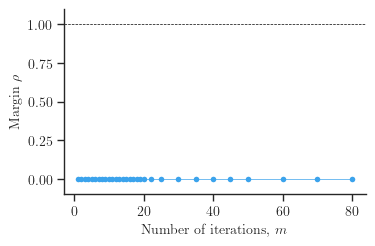

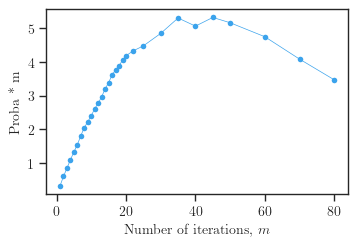

In [9]:
# Two diagnostic plots derived from the M8B heuristic curve loaded above:
# (1) the margin lower bound rho = 1 - mean_p * m * (c_gen/c_score), and
# (2) the product p * m used in the misreporting condition.

fig_width, fig_height = utils.get_fig_dim(469, fraction=0.6)
fig, ax = plt.subplots(figsize=(fig_width, fig_height))

sns.lineplot(
    x=splits[0:30],
    y=np.maximum(0, [1 - mean_095[i] * splits[i] * gen_to_score_ratio_M8
                     for i in range(len(splits))][0:30]),
    color=palette[2], ax=ax, linewidth=0.5, markersize=4, marker="o",
    err_style="band", linestyle="-", markeredgewidth=0,
)
ax.axhline(y=1, color="black", linestyle="--", linewidth=0.5, label="No margin")
ax.set_xlabel("Number of iterations, $m$")
ax.set_ylabel(r"Margin $\rho$")
sns.despine(ax=ax)
ax.set_ylim(-0.1, 1.1)

fig_width, fig_height = utils.get_fig_dim(469, fraction=0.6)
fig, ax = plt.subplots(figsize=(fig_width, fig_height))
sns.lineplot(
    x=splits[0:30],
    y=[mean_095[i] / 100 * splits[i] for i in range(len(splits))][0:30],
    color=palette[2], ax=ax, linewidth=0.5, markersize=4, marker="o",
    err_style="band", linestyle="-", markeredgewidth=0,
)
ax.set_xlabel("Number of iterations, $m$")
ax.set_ylabel(r"Proba * m")
print(splits)
print(mean_095)
print([mean_095[i] / 100 * splits[i] for i in range(len(splits))])


Probs 0:  [0.3    0.2925 0.275  0.265  0.26   0.255  0.25   0.25   0.2425 0.22
 0.2075 0.1975 0.1975 0.1975 0.2025 0.1975 0.2075 0.195  0.1975 0.195
 0.1825 0.175  0.175  0.165  0.1475 0.135  0.115  0.0875 0.0675 0.0575
 0.045  0.02  ]
Probs 1:  [0.2875 0.2775 0.25   0.2525 0.2475 0.24   0.2475 0.2525 0.25   0.2525
 0.2525 0.245  0.2475 0.245  0.24   0.2425 0.2225 0.215  0.2075 0.1975
 0.195  0.17   0.14   0.135  0.1025 0.09   0.0825 0.0525 0.0475 0.0375
 0.0225 0.015 ]
Probs 2:  [0.345  0.3225 0.3125 0.3    0.285  0.275  0.2775 0.265  0.2475 0.2475
 0.2525 0.25   0.24   0.2425 0.235  0.2375 0.235  0.2375 0.235  0.235
 0.2125 0.1925 0.17   0.155  0.13   0.13   0.1125 0.0975 0.06   0.035
 0.0225 0.015 ]
Meana array of probas, [31.08333333 29.75       27.91666667 27.25       26.41666667 25.66666667
 25.83333333 25.58333333 24.66666667 24.         23.75       23.08333333
 22.83333333 22.83333333 22.58333333 22.58333333 22.16666667 21.58333333
 21.33333333 20.91666667 19.66666667 17.916666

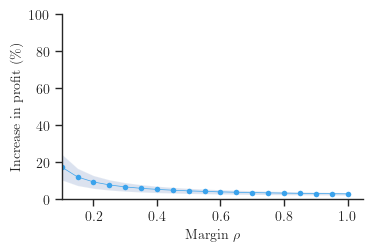

In [10]:
def get_profit_naive(splits, c0_to_cv, rho_array, data):
    """First (exploratory) version of the profit-increase formula.

    Per-rho increase is
    ``num_prompts * max(0, p_max*m - (1-rho)/c0_to_cv) / (rho * total_tokens) * 100``,
    averaged over three replicates with std as the spread.
    Superseded by ``get_profit`` in the next cell.
    """
    probs_0 = np.array([data["top_p_count"][0][i] / len(data["generated_outputs"][0])
                        for i in range(len(splits))])
    probs_1 = np.array([data["top_p_count"][1][i] / len(data["generated_outputs"][0])
                        for i in range(len(splits))])
    probs_2 = np.array([data["top_p_count"][2][i] / len(data["generated_outputs"][0])
                        for i in range(len(splits))])
    print("Probs 0: ", probs_0)
    print("Probs 1: ", probs_1)
    print("Probs 2: ", probs_2)
    print("Mean array of probas,",
          np.mean(np.stack((probs_0, probs_1, probs_2), axis=0), axis=0) * 100)

    proba_m_0 = max([probs_0[i] * splits[i] for i in range(len(splits))])
    proba_m_1 = max([probs_1[i] * splits[i] for i in range(len(splits))])
    proba_m_2 = max([probs_2[i] * splits[i] for i in range(len(splits))])
    print("Proba m 0: ", proba_m_0)
    print("Proba m 1: ", proba_m_1)
    print("Proba m 2: ", proba_m_2)

    num_prompts = len(data_095["generated_outputs"][0])
    print("Number of prompts: ", num_prompts)
    total_num_tokens = sum(data_095["generated_outputs"][0])
    print("Total number of tokens: ", total_num_tokens)

    increase_0 = [(num_prompts) * max(0, (proba_m_0 - (1 - rho_array[i]) / c0_to_cv))
                  / (rho_array[i] * total_num_tokens) * 100 for i in range(len(rho_array))]
    increase_1 = [(num_prompts) * max(0, (proba_m_1 - (1 - rho_array[i]) / c0_to_cv))
                  / (rho_array[i] * total_num_tokens) * 100 for i in range(len(rho_array))]
    increase_2 = [(num_prompts) * max(0, (proba_m_2 - (1 - rho_array[i]) / c0_to_cv))
                  / (rho_array[i] * total_num_tokens) * 100 for i in range(len(rho_array))]

    mean = np.mean(np.stack((increase_0, increase_1, increase_2), axis=0), axis=0)
    std = np.std(np.stack((increase_0, increase_1, increase_2), axis=0), axis=0)
    return mean, std


rho_range = np.arange(0.1, 1.01, 0.05)

fig_width, fig_height = utils.get_fig_dim(469, fraction=0.6)
fig, ax = plt.subplots(figsize=(fig_width, fig_height))

mean, std = get_profit_naive(splits, gen_to_score_ratio_M8, rho_range, data_095)

sns.lineplot(x=rho_range, y=mean, color=palette[2],
             linewidth=0.5, markersize=4, marker="o", linestyle="-", markeredgewidth=0)
ax.fill_between(rho_range, mean - std * t_val, mean + std * t_val, alpha=0.2)
print(mean)
ax.set_xlabel(r"Margin $\rho$")
ax.set_ylabel(r"Increase in profit $(\%)$")
ax.set_xlim(0.1, 1.05)
ax.set_ylim(-0.1, 100)
sns.despine(ax=ax)


Rho min=  -9.697618691981964
Optimal m  80
Rho min=  -2.682972536964129
Optimal m  45
Rho min=  -0.3447571519581847
Optimal m  20
Model:  L3B
Temp:  1.45
-------------------------
Lim 0.99:  17.54729051024256
Lim 0.95:  5.872378524582903
Lim 0.9:  2.266390446007522


<Figure size 640x480 with 0 Axes>

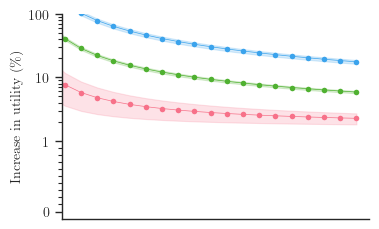

In [14]:
# Final profit / utility plot: choose ``model`` and ``temp``, load the
# three top-p variants of the heuristic-misreporting pickles, and plot
# the per-rho utility increase. Output figure goes to
# FIGURES_DIR/heur/profit/<model>_profit_<temp>.pdf.

SPLITS_T13_T115 = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18,
                   19, 20, 22, 25, 30, 35, 40, 45, 50, 60, 70, 80, 90, 100]
SPLITS_T145 = [1, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 60, 70, 80, 90, 100,
               110, 120, 130, 140, 150, 160, 170, 180, 190, 200]

model = "L3B"
temp = "1.45"

# Pick the right energy ratio and split-list for this (model, temp).
gen_to_score = gen_to_score_ratios[model]
splits = SPLITS_T13_T115 if temp in ("1.15", "1.3") else SPLITS_T145

# ``load_heur`` was defined in the cell above; for T=1.15 / T=1.3 we pass
# the splits list, for T=1.45 we leave it as ``None`` so the filename
# omits it (with the M8B/L1B sub-flavor handled by load_heur).
if temp in ("1.15", "1.3"):
    data_09  = load_heur(model, temp, 0.9,  splits=SPLITS_T13_T115)
    data_095 = load_heur(model, temp, 0.95, splits=SPLITS_T13_T115)
    data_099 = load_heur(model, temp, 0.99, splits=SPLITS_T13_T115)
elif temp == "1.45":
    data_09  = load_heur(model, temp, 0.9,  splits=None)
    data_095 = load_heur(model, temp, 0.95, splits=None)
    data_099 = load_heur(model, temp, 0.99, splits=None)
else:
    raise ValueError(f"Unsupported temp: {temp!r}")


def get_profit(splits, c0_to_cv, rho_array, data):
    """Per-rho utility increase formula used in the final plot.

    For each of three replicates we form ``coef = max(p_m - 1/c0_to_cv)``,
    and the increase is
    ``100 * num_prompts/total_tokens * max(0, coef/rho + 1/c0_to_cv)``.

    Also reports the implied lower-bound ``rho_min`` at which misreporting
    becomes worthwhile.
    """
    probs_0 = np.array([data["top_p_count"][0][i] / len(data["generated_outputs"][0])
                        for i in range(len(splits))])
    probs_1 = np.array([data["top_p_count"][1][i] / len(data["generated_outputs"][0])
                        for i in range(len(splits))])
    probs_2 = np.array([data["top_p_count"][2][i] / len(data["generated_outputs"][0])
                        for i in range(len(splits))])
    mean_probs = np.mean(np.stack((probs_0, probs_1, probs_2), axis=0), axis=0)
    rho_min = 1 - c0_to_cv * max([mean_probs[i] * splits[i] for i in range(len(splits))])
    print("Rho min= ", rho_min)

    coef_0 = max([probs_0[i] * splits[i] - 1 / c0_to_cv for i in range(len(splits))])
    coef_1 = max([probs_1[i] * splits[i] - 1 / c0_to_cv for i in range(len(splits))])
    coef_2 = max([probs_2[i] * splits[i] - 1 / c0_to_cv for i in range(len(splits))])

    print("Optimal m ",
          splits[np.argmax([mean_probs[i] * splits[i] for i in range(len(splits))])])

    num_prompts = len(data_095["generated_outputs"][0])
    total_num_tokens = sum(data_095["generated_outputs"][0])

    increase_0 = [100 * num_prompts / total_num_tokens
                  * max(0, 1 / rho * coef_0 + 1 / c0_to_cv) for rho in rho_array]
    increase_1 = [100 * num_prompts / total_num_tokens
                  * max(0, 1 / rho * coef_1 + 1 / c0_to_cv) for rho in rho_array]
    increase_2 = [100 * num_prompts / total_num_tokens
                  * max(0, 1 / rho * coef_2 + 1 / c0_to_cv) for rho in rho_array]

    mean = np.mean(np.stack((increase_0, increase_1, increase_2), axis=0), axis=0)
    std = np.std(np.stack((increase_0, increase_1, increase_2), axis=0), axis=0)
    return mean, std, rho_min


rho_range = np.arange(0.01, 1.05, 0.05)

plt.clf()
sns.set_theme(context="paper", style="ticks", font_scale=1)
width_pt = 469
palette = sns.color_palette("husl", 3)
utils.latexify()  # Computer Modern, with TeX

fig_width, fig_height = utils.get_fig_dim(width_pt, fraction=0.6)
fig, ax = plt.subplots(figsize=(fig_width, fig_height))

mean_099, std_099, rho_min_099 = get_profit(splits, gen_to_score, rho_range, data_099)
mean_095, std_095, rho_min_095 = get_profit(splits, gen_to_score, rho_range, data_095)
mean_09,  std_09,  rho_min_09  = get_profit(splits, gen_to_score, rho_range, data_09)
print("Model: ", model)
print("Temp: ", temp)
print("-------------------------")
print("Lim 0.99: ", mean_099[-1])
print("Lim 0.95: ", mean_095[-1])
print("Lim 0.9: ",  mean_09[-1])

sns.lineplot(x=rho_range[mean_099 > 0], y=mean_099[mean_099 > 0],
             color=palette[2], linewidth=0.5, markersize=4, marker="o",
             linestyle="-", markeredgewidth=0)
sns.lineplot(x=rho_range[mean_095 > 0], y=mean_095[mean_095 > 0],
             color=palette[1], linewidth=0.5, markersize=4, marker="o",
             linestyle="-", markeredgewidth=0)
sns.lineplot(x=rho_range[mean_09  > 0], y=mean_09[mean_09 > 0],
             color=palette[0], linewidth=0.5, markersize=4, marker="o",
             linestyle="-", markeredgewidth=0)

std_095[:] *= 0.3

ax.fill_between(rho_range[mean_099 > 0],
                mean_099[mean_099 > 0] - std_099[mean_099 > 0] * t_val,
                mean_099[mean_099 > 0] + std_099[mean_099 > 0] * t_val,
                alpha=0.2, color=palette[2])
ax.fill_between(rho_range[mean_095 > 0],
                mean_095[mean_095 > 0] - std_095[mean_095 > 0] * t_val,
                mean_095[mean_095 > 0] + std_095[mean_095 > 0] * t_val,
                alpha=0.2, color=palette[1])
ax.fill_between(rho_range[mean_09  > 0],
                mean_09[mean_09 > 0]   - std_09[mean_09 > 0]   * t_val,
                mean_09[mean_09 > 0]   + std_09[mean_09 > 0]   * t_val,
                alpha=0.2, color=palette[0])

ax.axvline(x=rho_range[mean_099 > 0][0], color=palette[2], linestyle="--", linewidth=0.5)
ax.axvline(x=rho_range[mean_095 > 0][0], color=palette[1], linestyle="--", linewidth=0.5)
ax.axvline(x=rho_range[mean_09  > 0][0], color=palette[0], linestyle="--", linewidth=0.5)

ax.set_ylabel(r"Increase in utility $(\%)$")
ax.set_xlim(0.1, 1.05)
ax.set_ylim(-0.1, 100)

ax.set_yscale("symlog", linthresh=1)
ax.get_yaxis().set_major_formatter(plt.ScalarFormatter())
ax.yaxis.set_minor_locator(plt.FixedLocator(
    [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1,
     2, 3, 4, 5, 6, 7, 8, 9, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
))

if model != "M8B":
    ax.get_xaxis().set_visible(False)
if temp != "1.45":
    ax.set_ylabel("")
    ax.tick_params(axis="y", which="both", labelleft=False, labelright=False)

sns.despine(ax=ax)
ax.set_xlabel(r"Provider's profit margin, $\rho_o$")
plt.tight_layout()

out_path = os.path.join(FIGURES_DIR, "heur", "profit", f"{model}_profit_{temp}.pdf")
os.makedirs(os.path.dirname(out_path), exist_ok=True)
fig.savefig(out_path, dpi=300)
